In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("/content/sample_data/Student_Performance.csv")

In [3]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
df.tail()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
9995,1,49,Yes,4,2,23.0
9996,7,64,Yes,8,5,58.0
9997,6,83,Yes,8,5,74.0
9998,9,97,Yes,7,0,95.0
9999,7,74,No,8,1,64.0


In [5]:
df.describe()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,4.992900,69.445700,6.530600,4.583300,55.224800
std,2.589309,17.343152,1.695863,2.867348,19.212558
min,1.000000,40.000000,4.000000,0.000000,10.000000
25%,3.000000,54.000000,5.000000,2.000000,40.000000
50%,5.000000,69.000000,7.000000,5.000000,55.000000
75%,7.000000,85.000000,8.000000,7.000000,71.000000
max,9.000000,99.000000,9.000000,9.000000,100.000000


In [7]:
df.shape

(10000, 6)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [12]:
df.isnull().sum()

,0
Hours Studied,0
Previous Scores,0
Extracurricular Activities,0
Sleep Hours,0
Sample Question Papers Practiced,0
Performance Index,0


In [15]:
df.select_dtypes(include='object').columns

Index(['Extracurricular Activities'], dtype='object')

In [20]:
from sklearn.preprocessing import LabelEncoder
df['Extracurricular Activities']=LabelEncoder().fit_transform(df['Extracurricular Activities'])

In [21]:
df['Extracurricular Activities']

,Extracurricular Activities
0,1
1,0
2,1
3,1
4,0
...,...
9995,1
9996,1
9997,1
9998,1


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  int64  
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 468.9 KB


In [23]:
print(df.dtypes)

Hours Studied                         int64
Previous Scores                       int64
Extracurricular Activities            int64
Sleep Hours                           int64
Sample Question Papers Practiced      int64
Performance Index                   float64
dtype: object


In [26]:
corealation_matrix=df.corr()

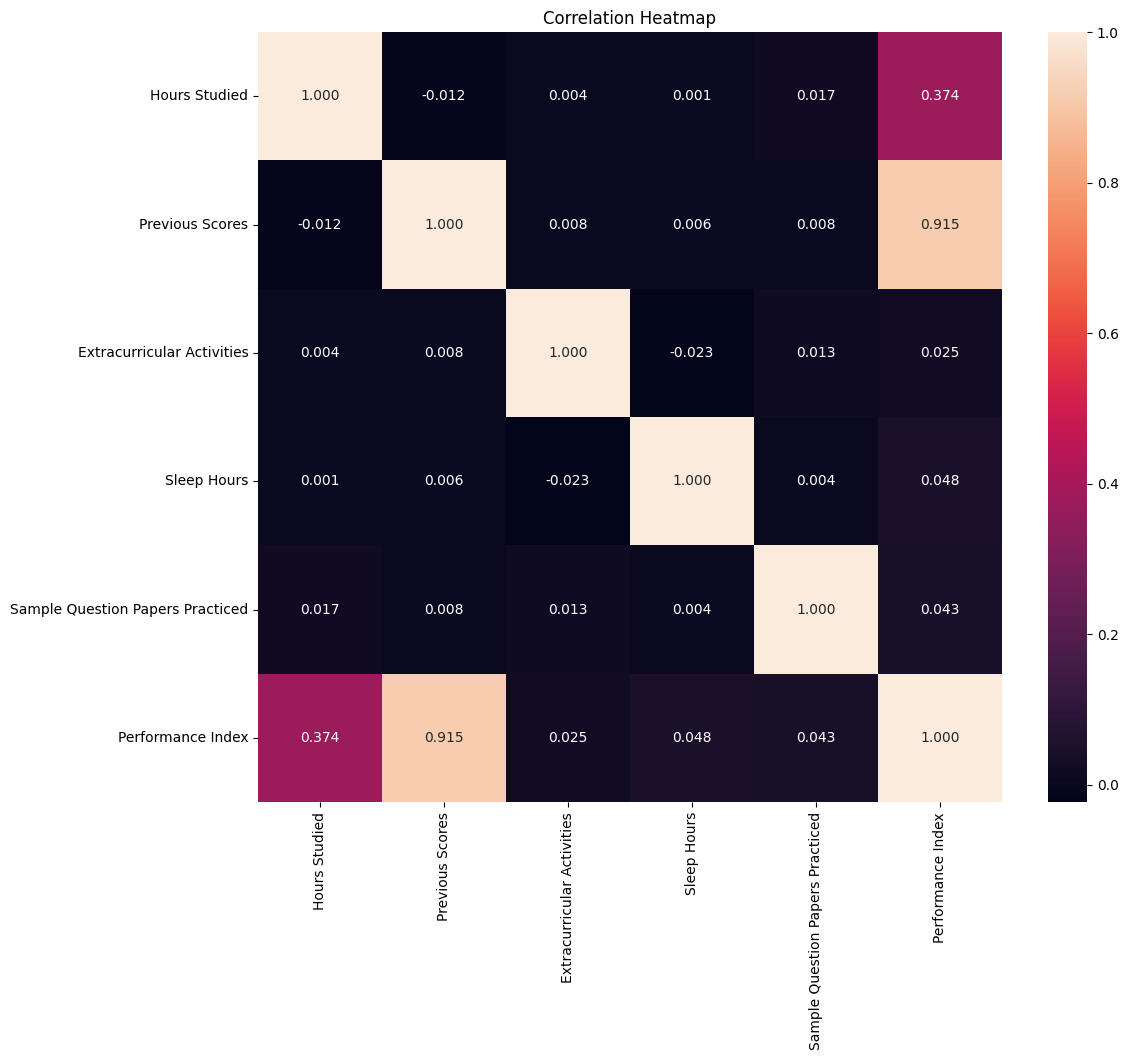

In [39]:
plt.figure(figsize=(12,10))
sns.heatmap(corealation_matrix, annot=True,fmt=".3f")

plt.title("Correlation Heatmap")
plt.show()

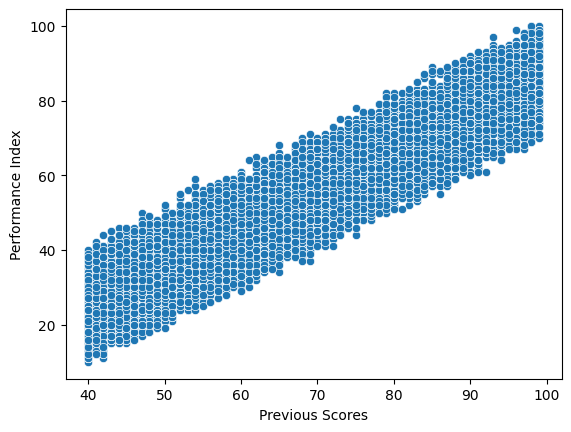

In [41]:
sns.scatterplot(
    x=df['Previous Scores'],
    y=df['Performance Index']
)
plt.show()

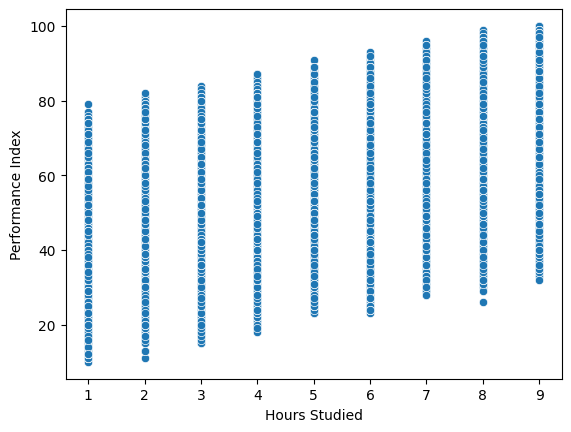

In [42]:
sns.scatterplot(
    x=df['Hours Studied'],
    y=df['Performance Index']
)
plt.show()

In [46]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols

Index(['Hours Studied', 'Previous Scores', 'Extracurricular Activities',
       'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index'],
      dtype='object')

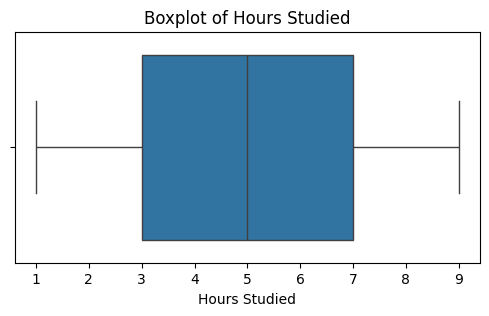

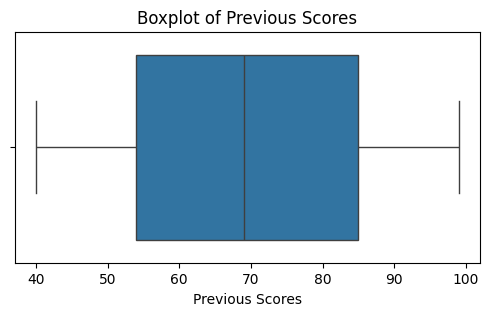

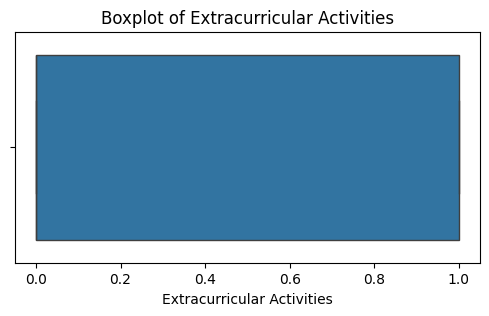

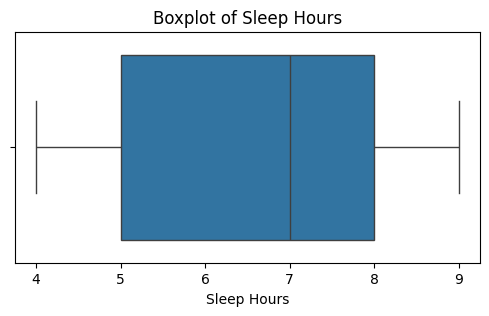

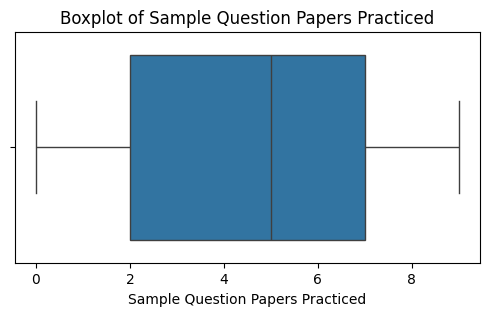

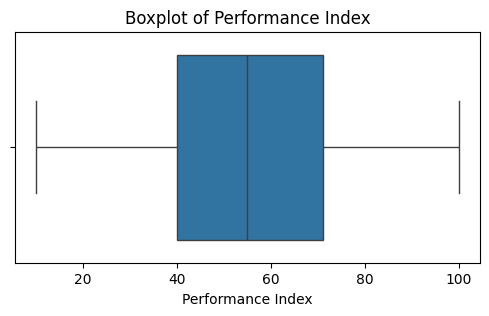

In [47]:
for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

In [48]:
Q1 = df['Previous Scores'].quantile(0.25)
Q3 = df['Previous Scores'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR

upper = Q3 + 1.5 * IQR

In [49]:
outliers = df[
    (df['Previous Scores'] < lower) |
    (df['Previous Scores'] > upper)
]

print(outliers)

Empty DataFrame
Columns: [Hours Studied, Previous Scores, Extracurricular Activities, Sleep Hours, Sample Question Papers Practiced, Performance Index]
Index: []


In [50]:
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower:", lower)
print("Upper:", upper)

Q1: 54.0
Q3: 85.0
IQR: 31.0
Lower: 7.5
Upper: 131.5


In [54]:
numerical_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numerical_cols:

  Q1=df[col].quantile(0.25)
  Q3=df[col].quantile(0.75)
  IQR=Q3-Q1

  lower_bound=Q1 - 1.5*IQR
  upper_bound=Q3 + 1.5*IQR
  outliers_count= ((df[col]<lower_bound) | (df[col]> upper_bound)).sum()
  print(f"{col}:{outliers_count}")

Hours Studied:0
Previous Scores:0
Extracurricular Activities:0
Sleep Hours:0
Sample Question Papers Practiced:0
Performance Index:0


In [55]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection  import train_test_split

In [56]:
x=df.drop("Performance Index",axis=1)
y=df["Performance Index"]

In [57]:
print(x,y)

      Hours Studied  Previous Scores  Extracurricular Activities  Sleep Hours  \
0                 7               99                           1            9   
1                 4               82                           0            4   
2                 8               51                           1            7   
3                 5               52                           1            5   
4                 7               75                           0            8   
...             ...              ...                         ...          ...   
9995              1               49                           1            4   
9996              7               64                           1            8   
9997              6               83                           1            8   
9998              9               97                           1            7   
9999              7               74                           0            8   

      Sample Question Paper

In [61]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [62]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((7000, 5), (7000,), (3000, 5), (3000,))

In [65]:
from sklearn.preprocessing import StandardScaler

sc=StandardScaler()


In [69]:
x_train_scaled=sc.fit_transform(x_train)
x_train_scaled

array([[-1.16924106,  0.95594992, -0.98300159,  0.86975099,  0.49086499],
       [ 0.37759332,  0.03401289,  1.01729235, -1.49095352, -0.20837289],
       [ 1.15101051,  0.55260247,  1.01729235,  0.86975099,  0.84048393],
       ...,
       [ 0.37759332,  1.41691844,  1.01729235, -0.90077739, -0.55799183],
       [ 0.76430192, -0.9455452 ,  1.01729235, -0.90077739, -1.25722971],
       [ 1.15101051,  0.37973928,  1.01729235,  1.45992712, -0.90761077]])

In [77]:
x_test_scaled=sc.fit_transform(x_test)
x_test_scaled

array([[ 0.41561603,  0.43149091,  0.99468081,  0.85897454, -0.19203649],
       [ 0.80092138,  0.43149091, -1.00534763,  0.27036704,  0.50165343],
       [ 1.18622673,  1.64446343, -1.00534763, -0.31824045,  0.8484984 ],
       ...,
       [ 0.80092138, -0.72372102,  0.99468081, -1.49545544, -0.53888146],
       [-1.5109107 ,  0.4892515 ,  0.99468081,  1.44758203,  1.19534336],
       [ 1.57153207, -1.64789055,  0.99468081, -0.90684795,  0.15480847]])

In [78]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()

In [79]:
model.fit(x_train_scaled, y_train)

LinearRegression()

In [80]:
y_pred=model.predict(x_test_scaled)

In [81]:
y_pred.shape

(3000,)

In [83]:
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
result

,Actual,Predicted
4602,61.0,66.846429
5951,66.0,69.016710
7756,94.0,93.022520
1516,34.0,33.797138
8617,33.0,30.776928
...,...,...
1683,46.0,49.024792
3129,33.0,33.816056
7345,47.0,47.215779
4575,56.0,54.873432


In [85]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
mae

1.621543642956028

In [86]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("RMSE:", rmse)

RMSE: 2.038983055299376


In [87]:
from sklearn.metrics import r2_score
r2 = r2_score(y_test, y_pred)

print("R2:", r2)

R2: 0.9888430174906566


In [91]:
n = len(y_test)

p = x_test.shape[1]

adjusted_r2 = 1 - (
    (1 - r2) * (n - 1)
    / (n - p - 1)
)

print(n,p)

print("Adjusted R2:", adjusted_r2)

3000 5
Adjusted R2: 0.9888243852553371


In [92]:
mae,rmse,r2,adjusted_r2

(1.621543642956028,
 np.float64(2.038983055299376),
 0.9888430174906566,
 0.9888243852553371)

In [95]:
residuals = y_test - y_pred
residuals

,Performance Index
4602,-5.846429
5951,-3.016710
7756,0.977480
1516,0.202862
8617,2.223072
...,...
1683,-3.024792
3129,-0.816056
7345,-0.215779
4575,1.126568


In [97]:
print(residuals.mean())

-0.1459047619047563


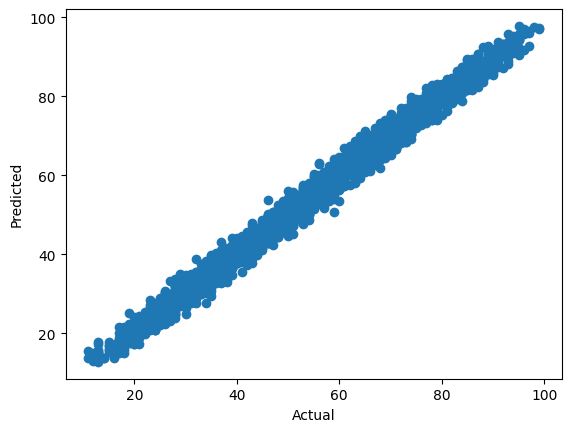

In [98]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()

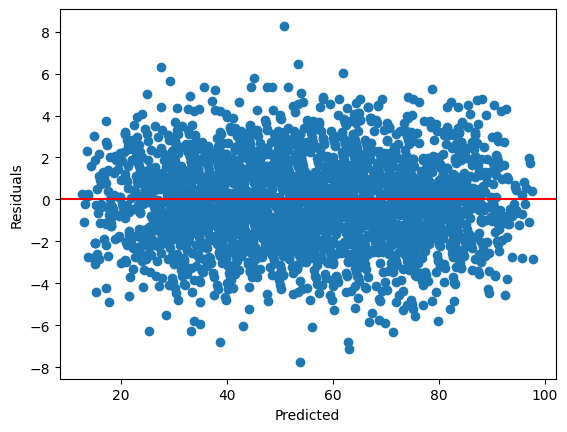

In [99]:
import matplotlib.pyplot as plt

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='r')

plt.xlabel("Predicted")
plt.ylabel("Residuals")

plt.show()

In [101]:
print(model.intercept_)
print(model.coef_)

55.26857142857143
[ 7.40382507 17.661619    0.30628505  0.79864815  0.57693968]
